In [ ]:
%pip install pyspark efficient_apriori

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [16]:
from pyspark.sql import SparkSession
from collections import Counter
from pyspark import RDD
import time
import matplotlib.pyplot as plt
import csv
import pandas as pd
import os
from pathlib import Path

In [17]:
spark = SparkSession.builder \
    .appName("FrequentItemsMining") \
    .master("local[*]") \
    .config("spark.driver.extraJavaOptions", "-Djava.security.manager=allow") \
    .config("spark.executor.extraJavaOptions", "-Djava.security.manager=allow") \
    .getOrCreate()

In [18]:
def plot_graph(filepath, dataset_name, partition):
    df = pd.read_csv(filepath)
    directory = Path(filepath).parent
    output_filename = f"{dataset_name}_{partition}_plot.png"
    output_path = directory / output_filename
    plt.figure(figsize=(8, 5))
    plt.plot(df["min_support"], df["elapsed"], marker='o')
    plt.title(f"{dataset_name} dataset using Pyspark with Parition {partition}")
    plt.xlabel("Minimum Support")
    plt.ylabel("Runtime (seconds)")
    plt.grid(True)
    plt.savefig(output_path)
    plt.tight_layout()
    plt.show()

In [19]:
def load_transactions(file_path, partitions, sc, num_lines) -> RDD:
    raw_rdd = sc.sparkContext.textFile(file_path)
    if num_lines is not None:
        raw_rdd = raw_rdd.zipWithIndex().filter(lambda x: x[1] < num_lines).keys()
    partitioned_rdd = raw_rdd.repartition(partitions)
    transactions_rdd = partitioned_rdd.map(lambda line: line.strip().split(','))
    transactions_rdd = transactions_rdd.persist()
    return transactions_rdd

In [ ]:
def generate_candidates(prev_frequents, k):
    candidates = set()
    prev_frequents = [set(itemset) for itemset in prev_frequents]

    for i in range(len(prev_frequents)):
        for j in range(i + 1, len(prev_frequents)):
            union = prev_frequents[i] | prev_frequents[j]
            if len(union) == k:
                candidates.add(frozenset(union))
    return candidates

def apriori_mapper(partition, global_support, total_transactions):
    partition = list(partition)
    partition_size = len(partition)
    if partition_size == 0:
        return iter([])

    local_support = max(1, int(global_support * (partition_size / total_transactions)))
    item_counts = Counter()

    for transaction in partition:
        for item in transaction:
            item_counts[frozenset([item])] += 1

    # Frequent 1-itemsets
    frequent_itemsets = set(item for item, count in item_counts.items() if count >= local_support)
    all_frequents = set(frequent_itemsets)

    k = 2
    current_frequents = frequent_itemsets

    while current_frequents:
        candidates = generate_candidates(current_frequents, k)
        if not candidates:
            break

        candidate_counts = Counter()
        for transaction in partition:
            t_set = set(transaction)
            for candidate in candidates:
                if candidate.issubset(t_set):
                    candidate_counts[candidate] += 1

        current_frequents = set(itemset for itemset, count in candidate_counts.items() if count >= local_support)
        all_frequents.update(current_frequents)
        k += 1

    return ((itemset, 1) for itemset in all_frequents)


In [ ]:
def son_phase1(transactions_rdd, min_support):
    total_transactions = transactions_rdd.count()
    global_support = max(1, int(min_support * total_transactions))
    sc = transactions_rdd.context
    total_transactions_b = sc.broadcast(total_transactions)

    mapped = transactions_rdd.mapPartitions(
        lambda partition: apriori_mapper(partition, global_support, total_transactions_b.value)
    )

    candidate_itemsets_rdd = mapped.reduceByKey(lambda a, b: 1).keys()

    return candidate_itemsets_rdd

In [ ]:
def son_phase2(transactions_rdd, candidates_rdd, min_support):
    transactions_rdd = transactions_rdd.persist()

    total_transactions = transactions_rdd.count()
    global_support = max(1, int(min_support * total_transactions))

    candidates = candidates_rdd.collect()
    candidates_b = transactions_rdd.context.broadcast(candidates)

    def emit_counts(transaction):
        transaction_set = set(transaction)

        for candidate in candidates_b.value:
            if len(candidate) > len(transaction_set):
                continue 
            if all(item in transaction_set for item in candidate):
                yield (candidate, 1)

    counts_rdd = transactions_rdd.flatMap(emit_counts)

    frequent_itemsets_rdd = counts_rdd.reduceByKey(lambda a, b: a + b) \
                                       .filter(lambda x: x[1] >= global_support)

    return frequent_itemsets_rdd



In [23]:
def main_loop(filePath, partition,min_support,spark):
    start_time1 = time.time()
    transactions_rdd= load_transactions(filePath, partition,spark, None)
    end_time1 = time.time()
    load_transactions_elapsed1 = end_time1 - start_time1
    # print(f'load_transactions took {load_transactions_elapsed1} secs')
    candidates_rdd = son_phase1(transactions_rdd, min_support)
    end_time2 = time.time()
    son_phase1_elapsed = end_time2 - end_time1
    # print(f'son_phase1 took {son_phase1_elapsed} secs')
    frequent_itemsets_rdd = son_phase2(transactions_rdd, candidates_rdd, min_support)
    end_time3 = time.time()
    frequent_itemsets_rdd_elapsed = end_time3 - end_time2
    return frequent_itemsets_rdd
    # print(f'son_phase2 took {frequent_itemsets_rdd_elapsed} secs')

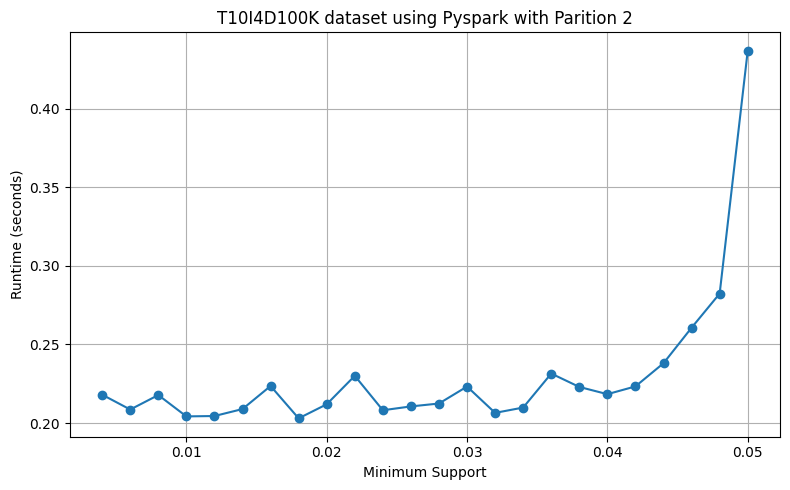

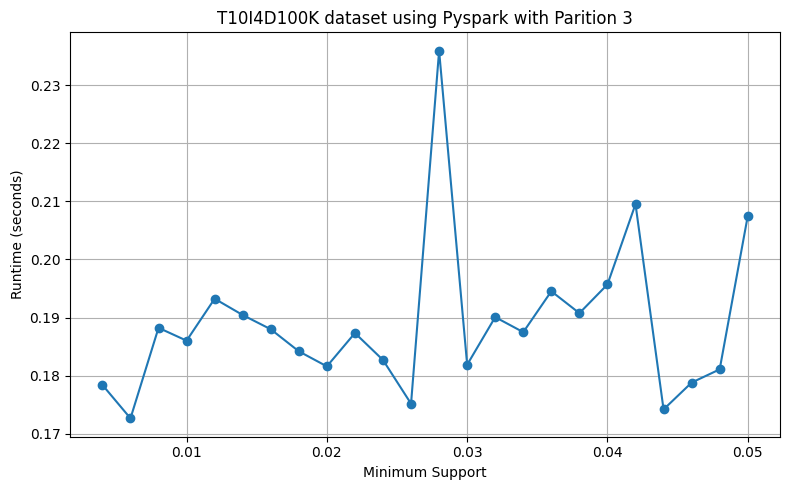

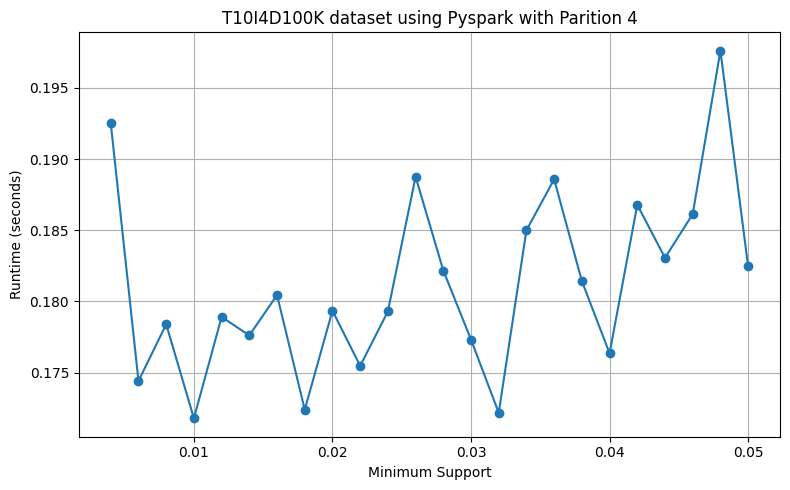

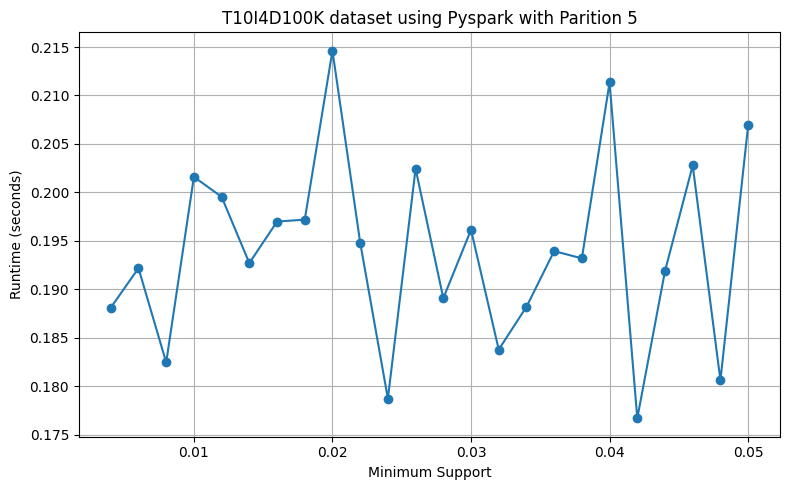

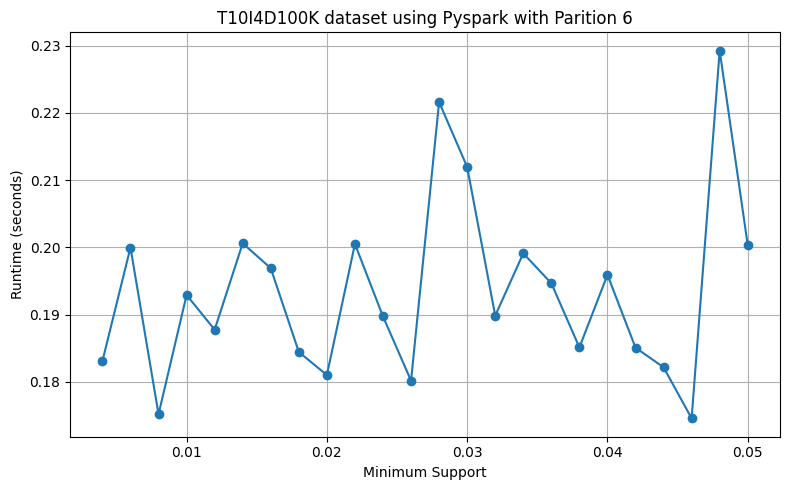

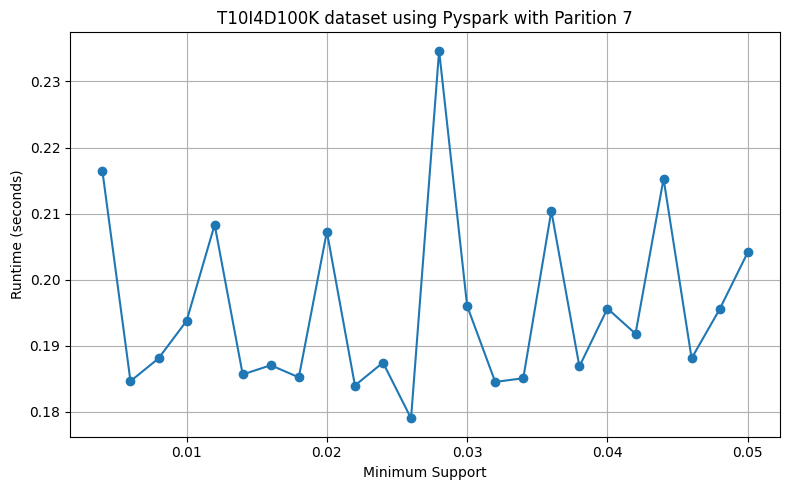

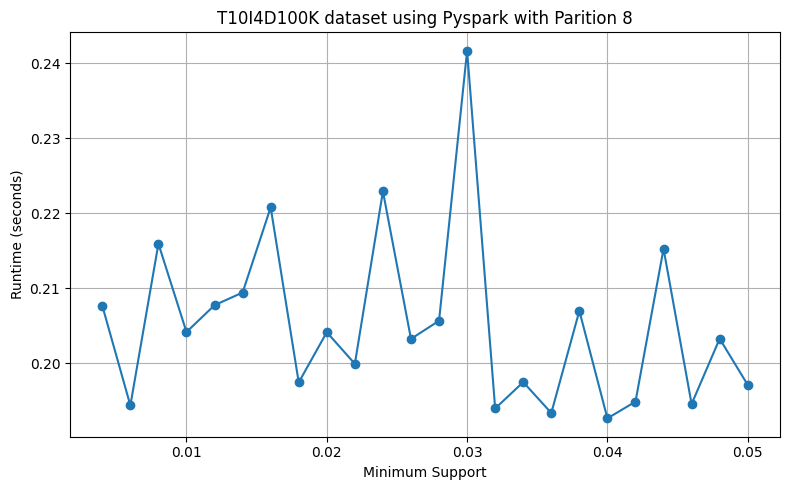

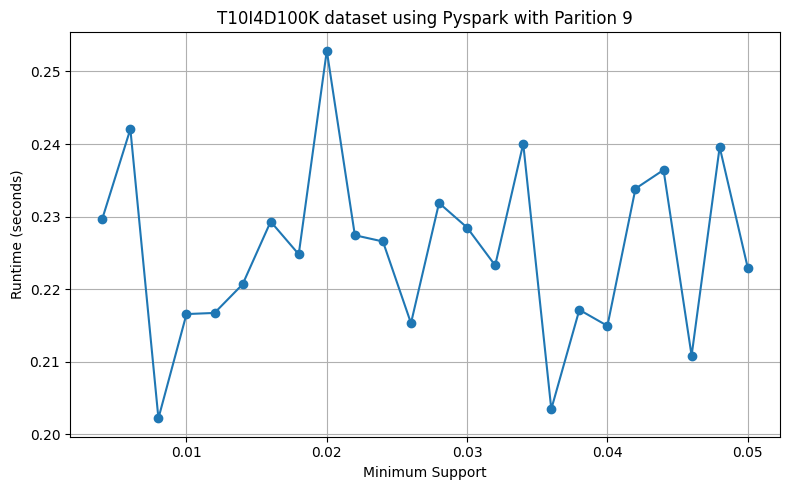

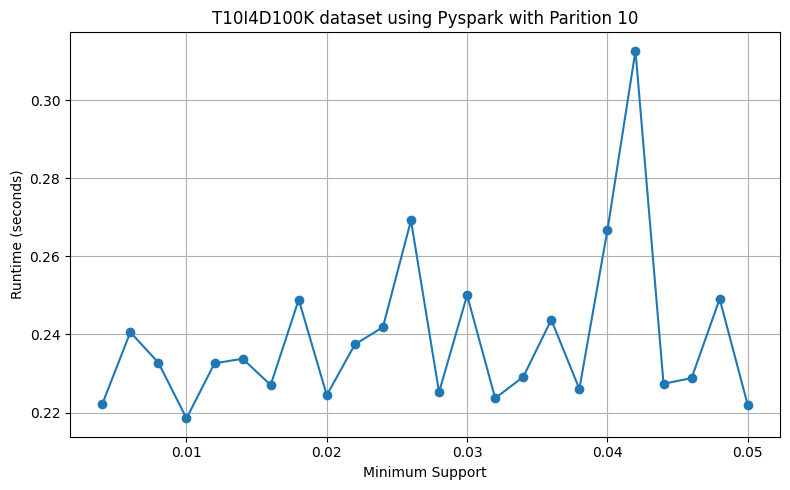

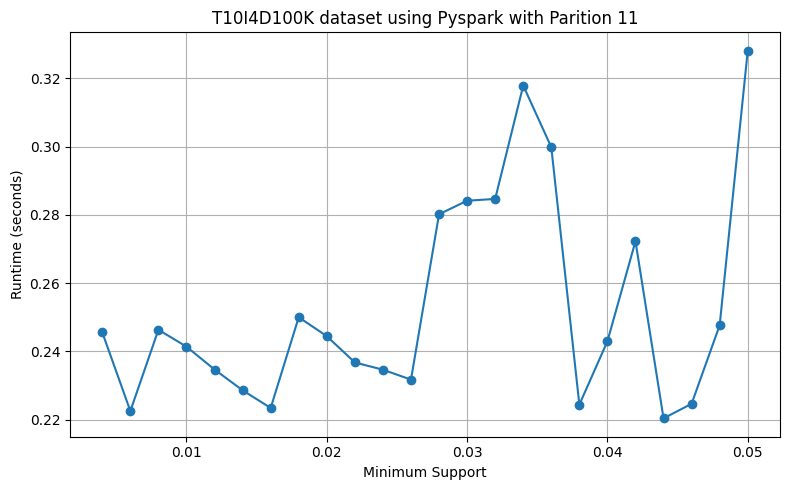

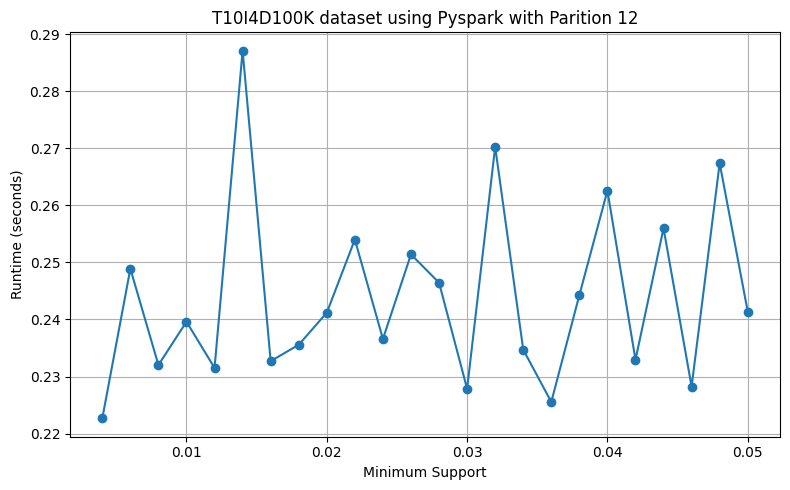

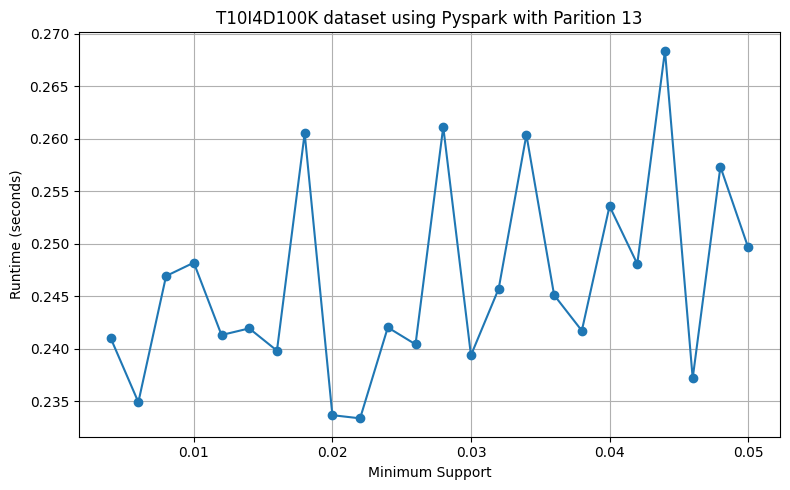

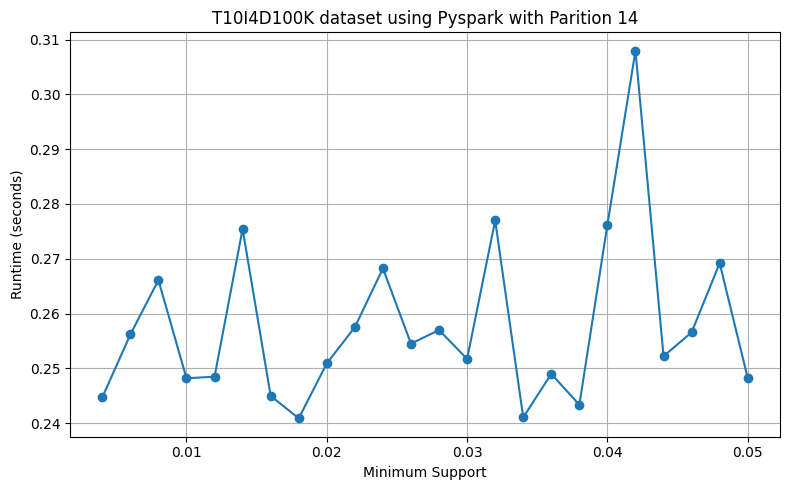

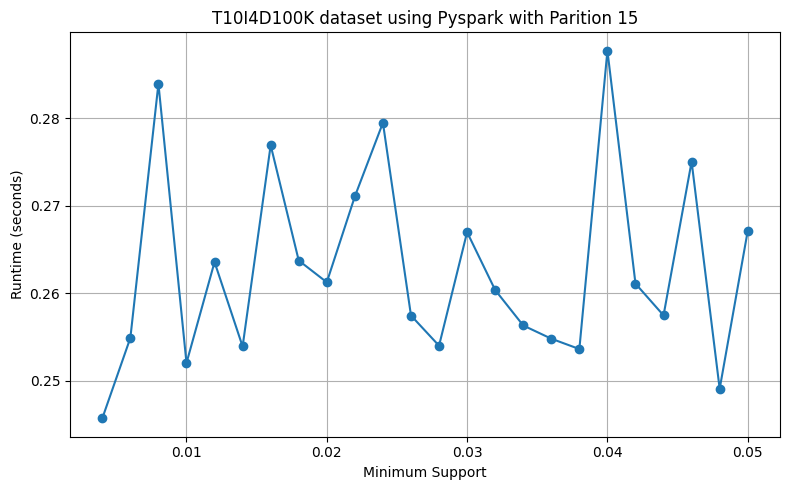

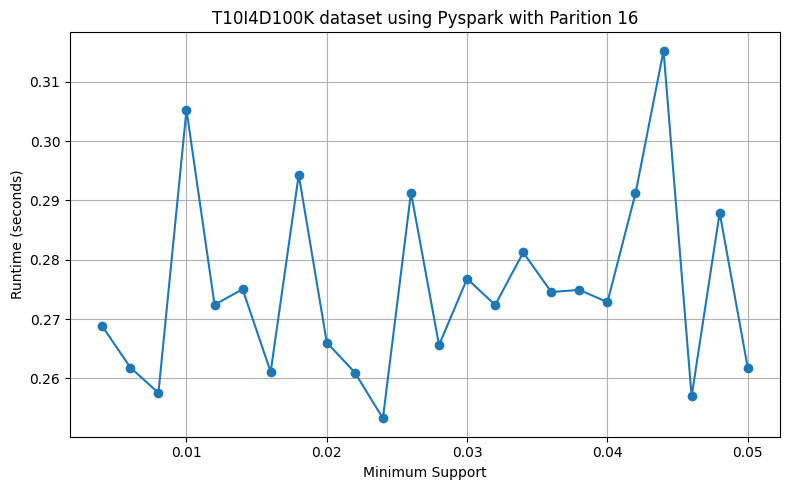

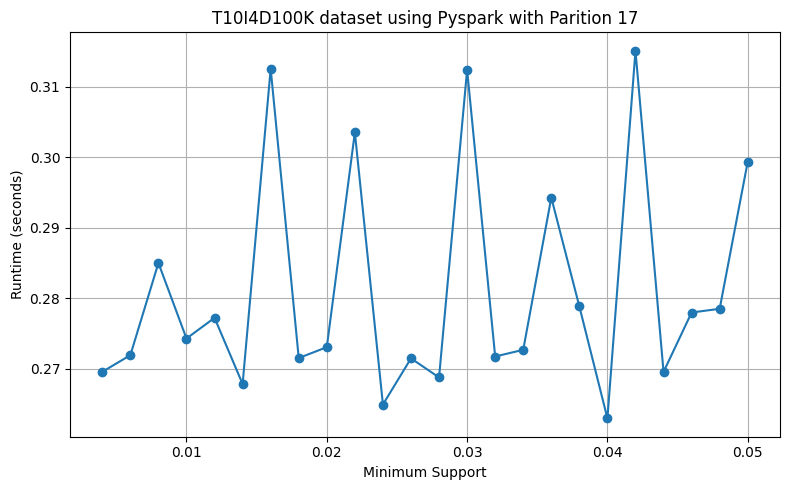

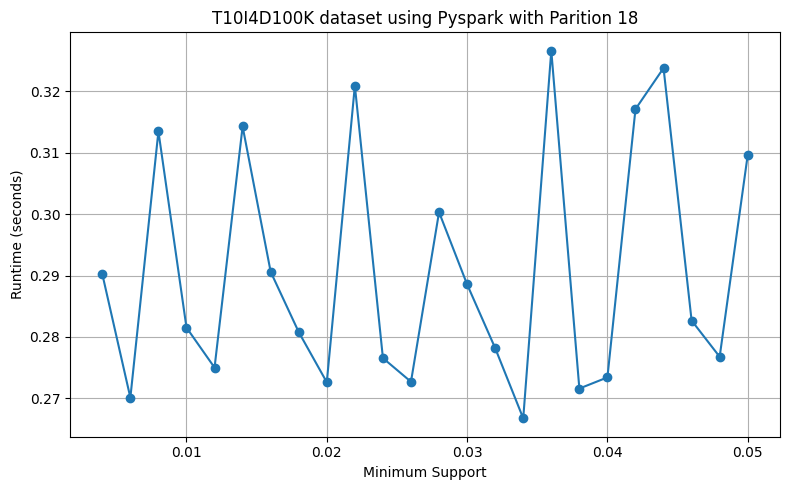

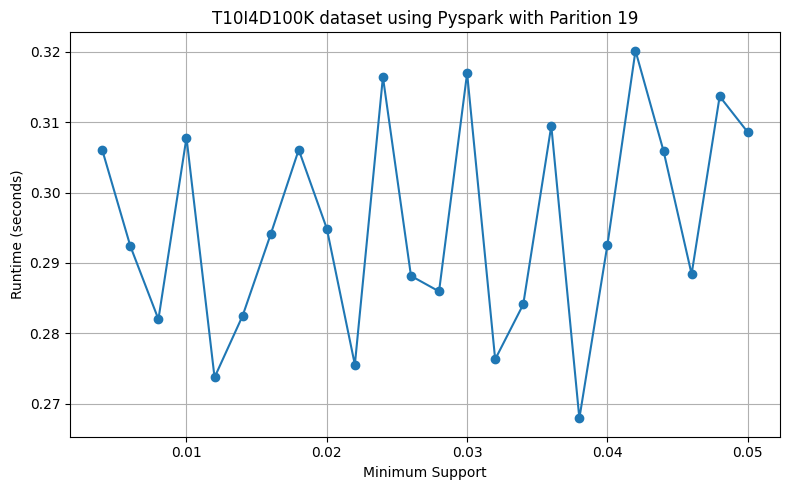

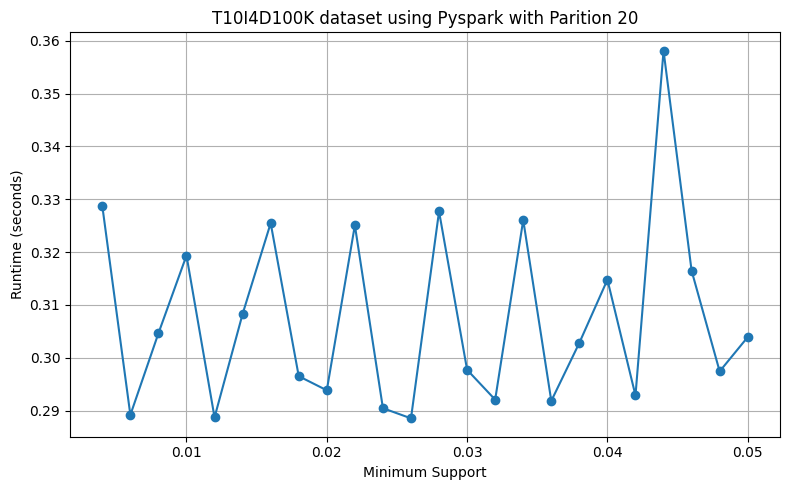

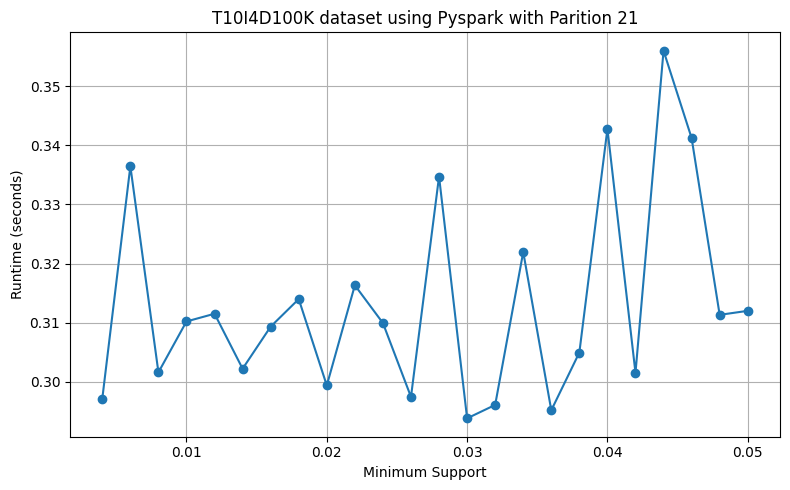

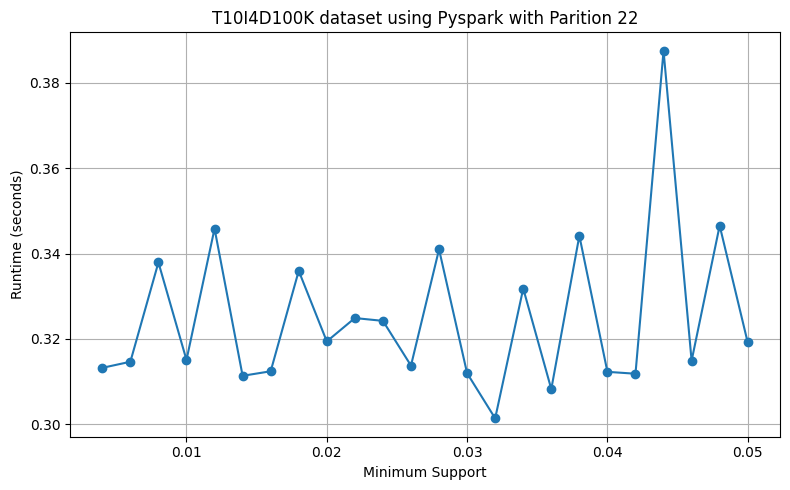

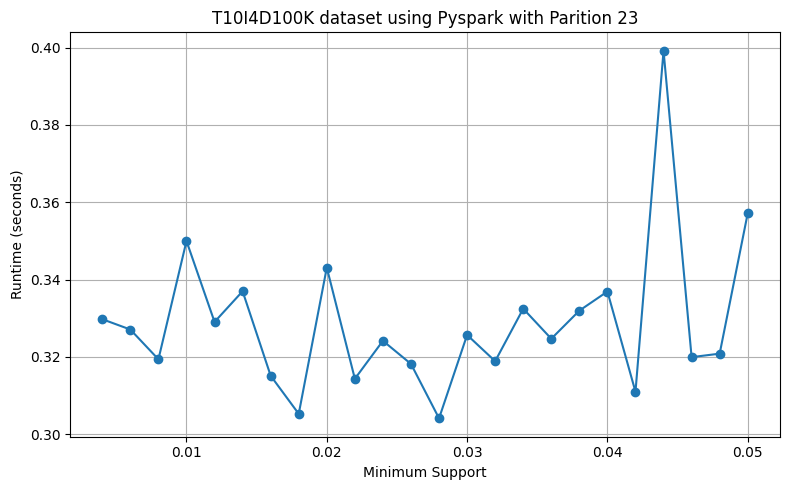

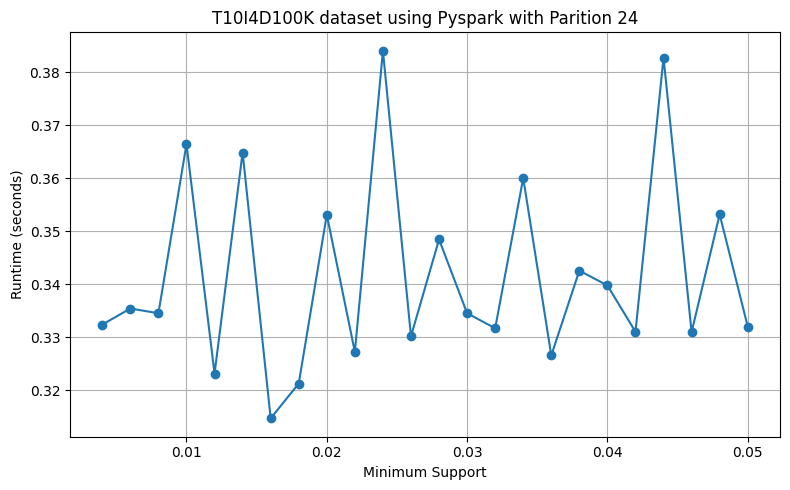

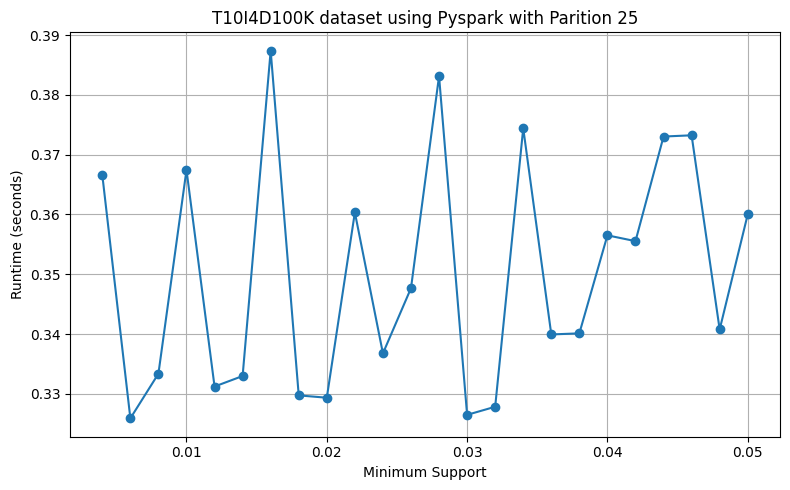

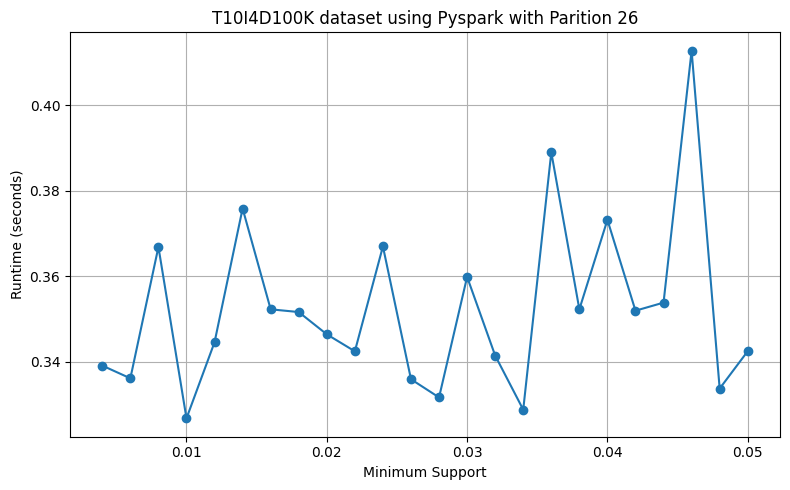

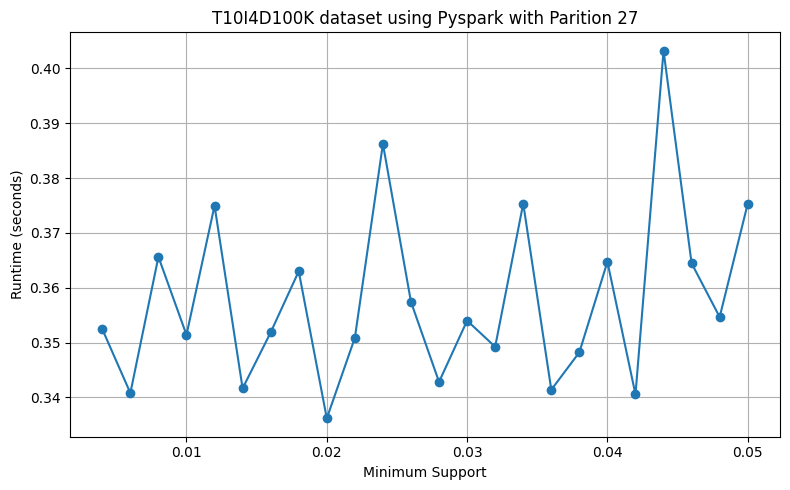

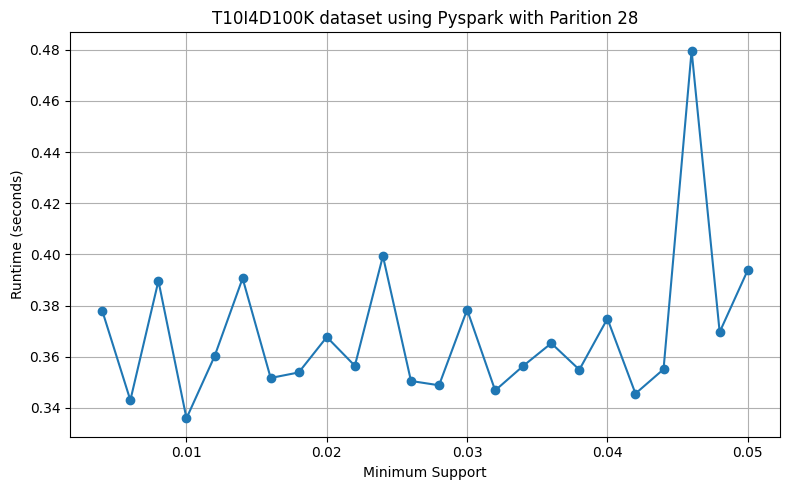

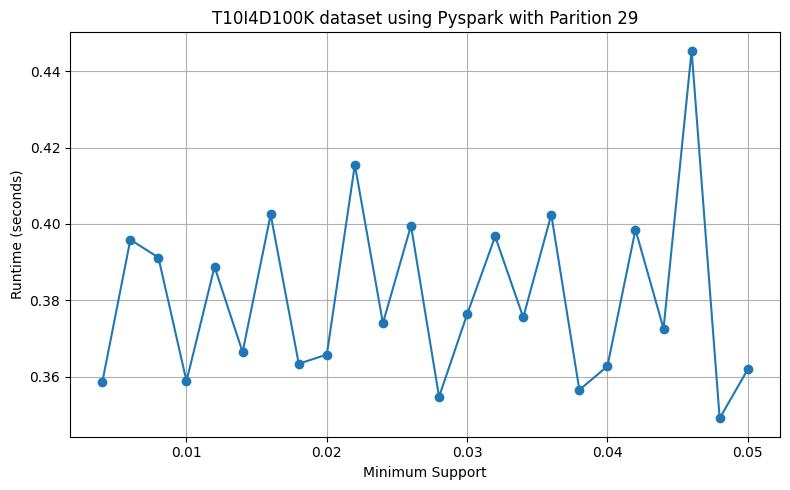

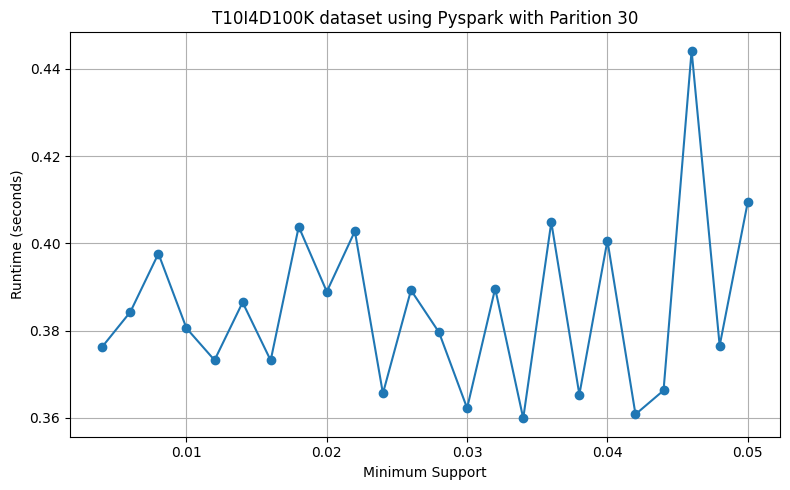

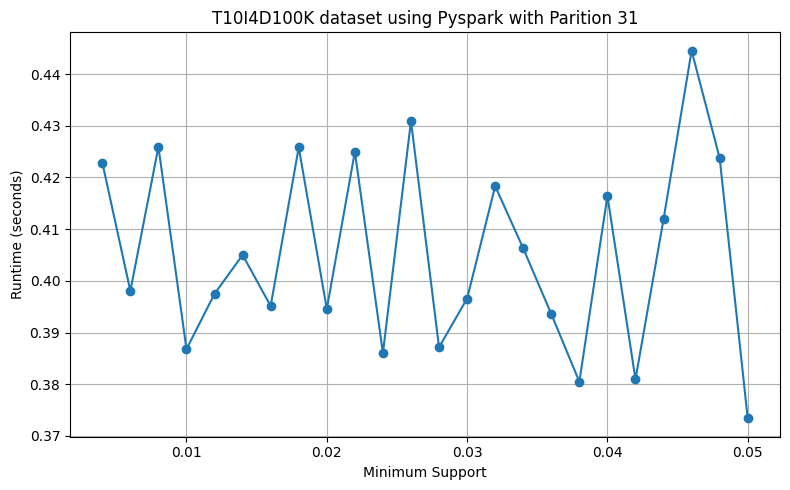

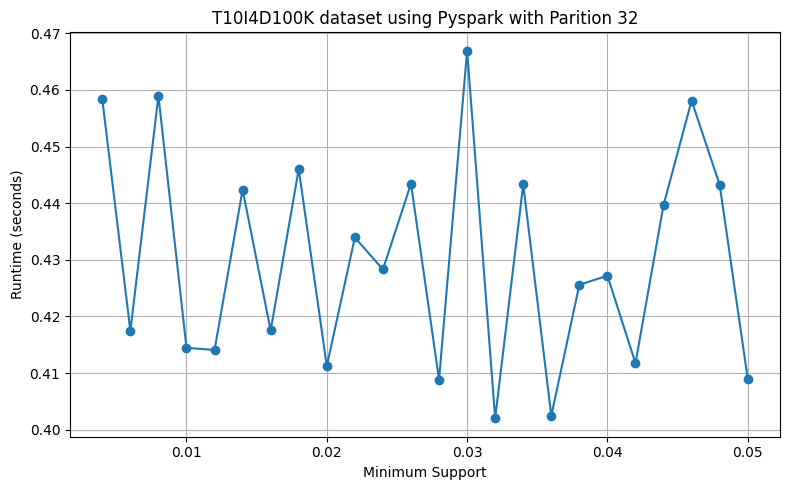

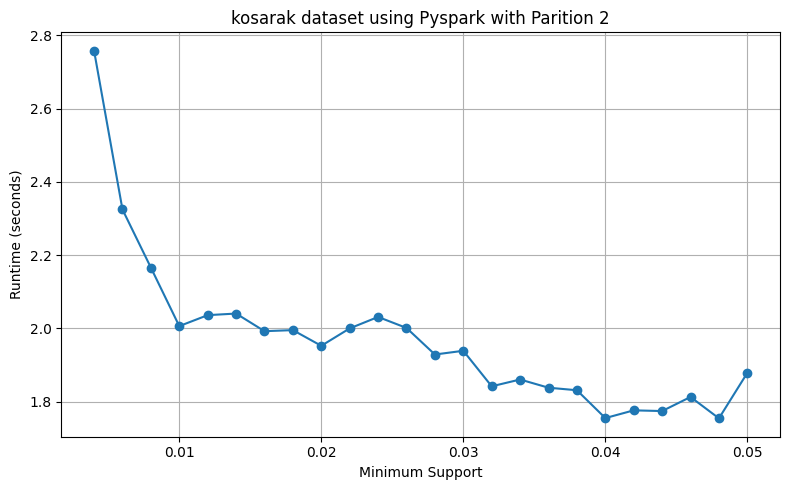

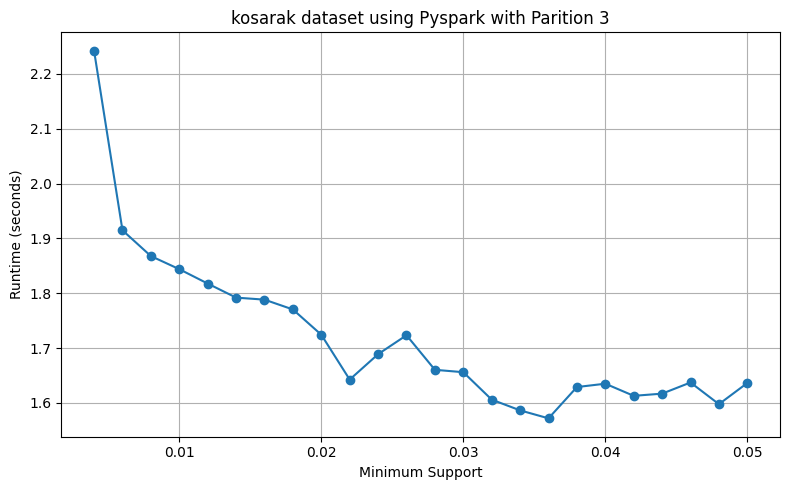

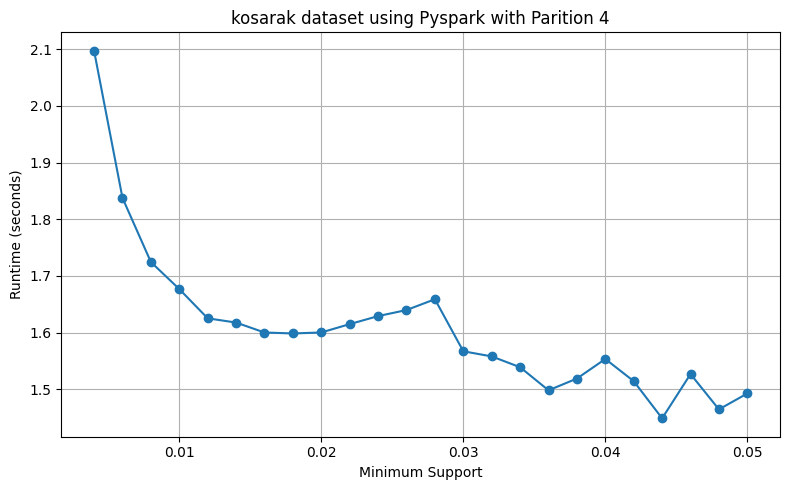

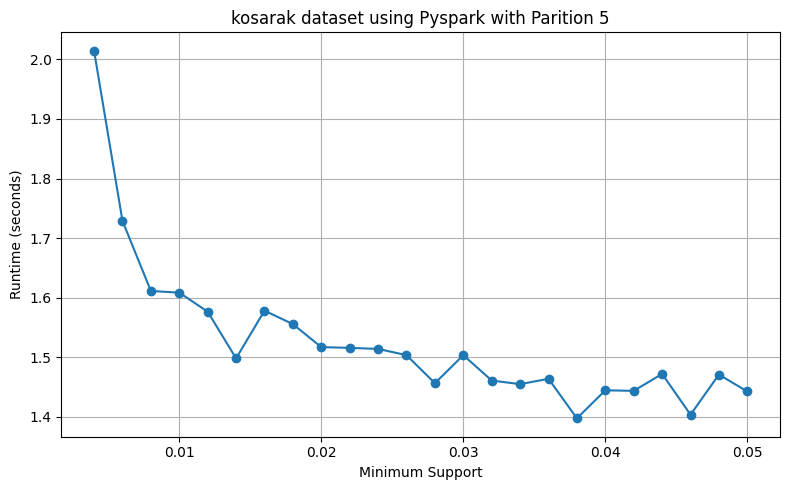

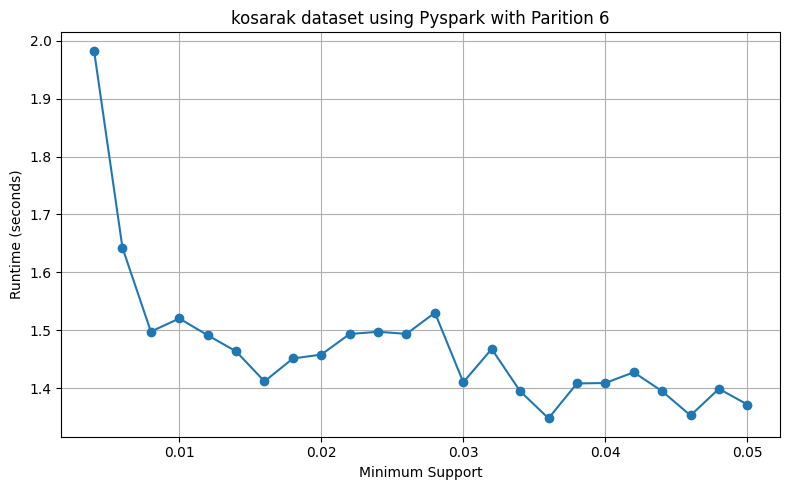

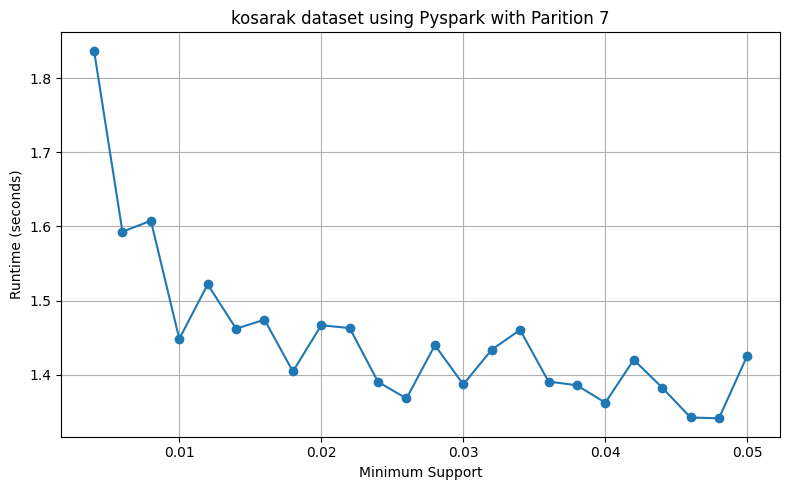

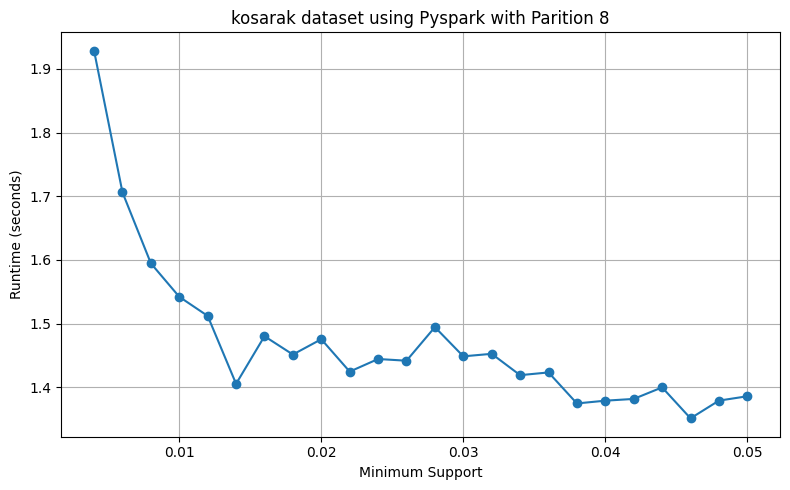

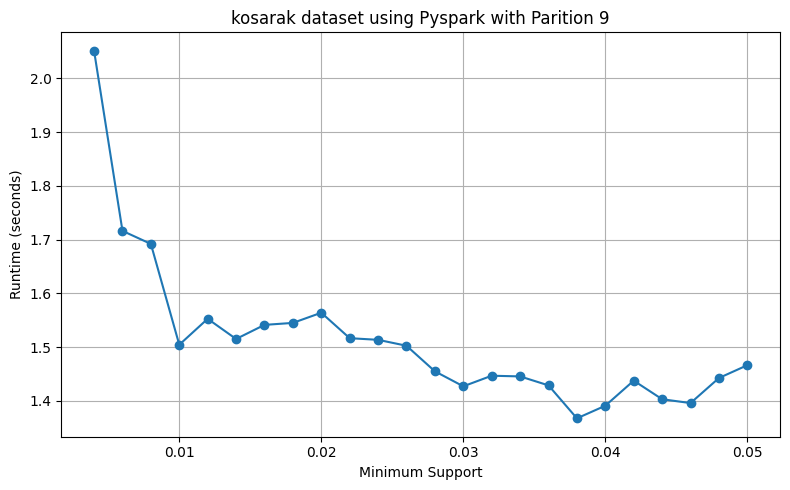

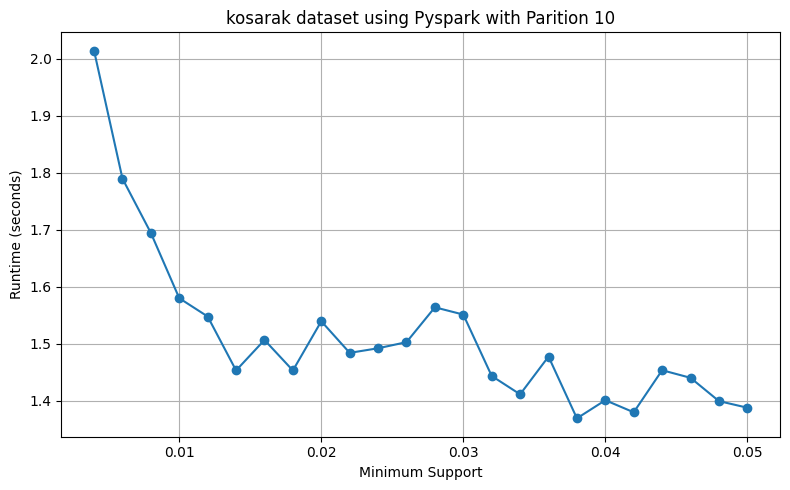

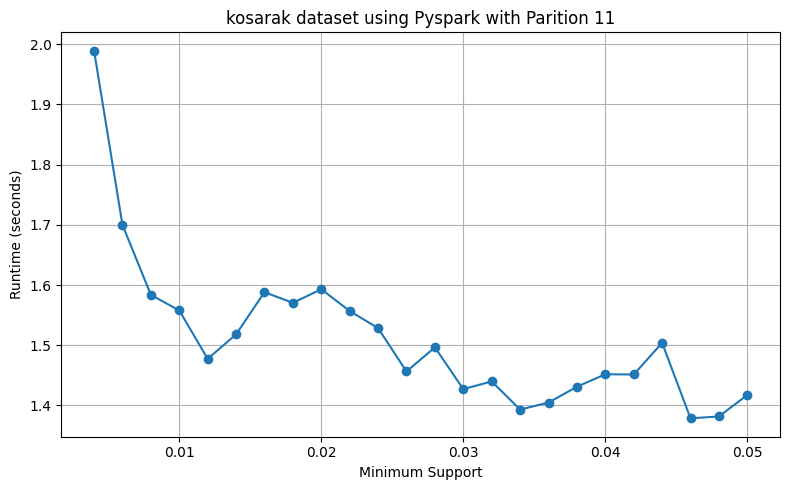

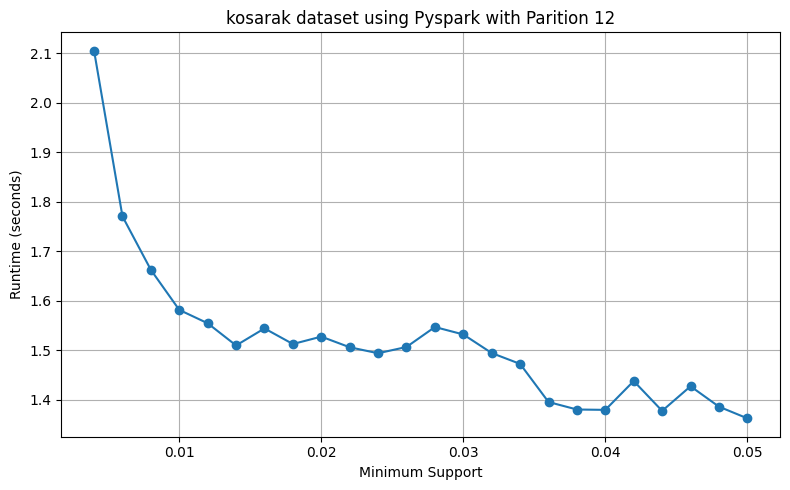

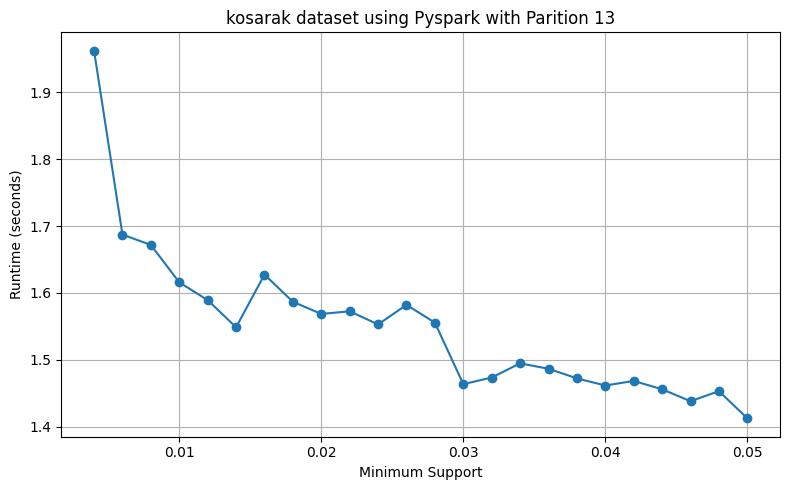

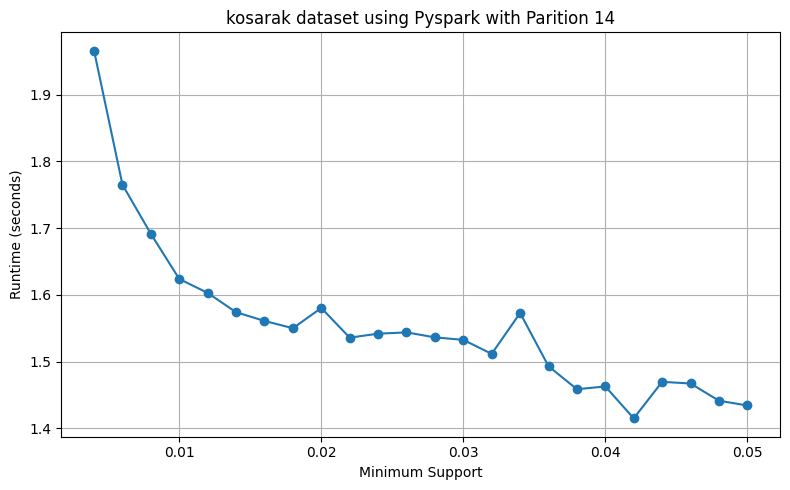

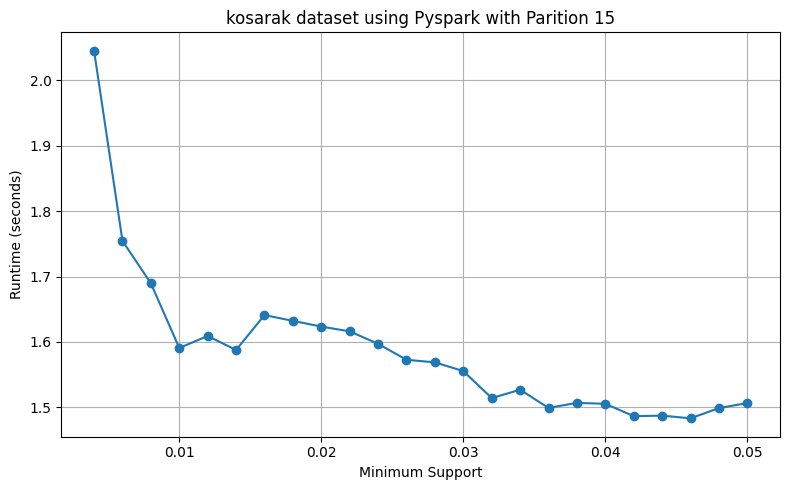

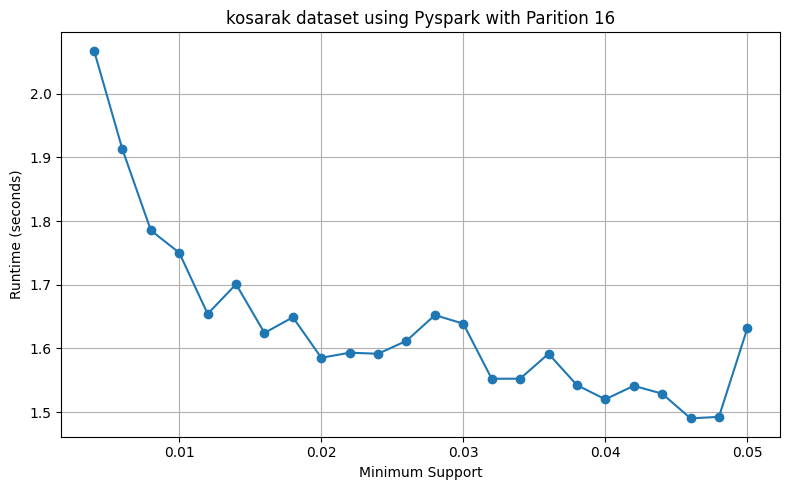

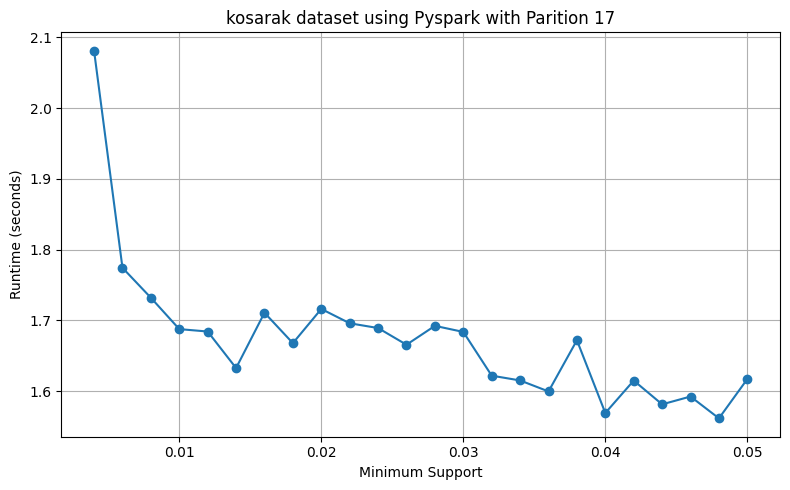

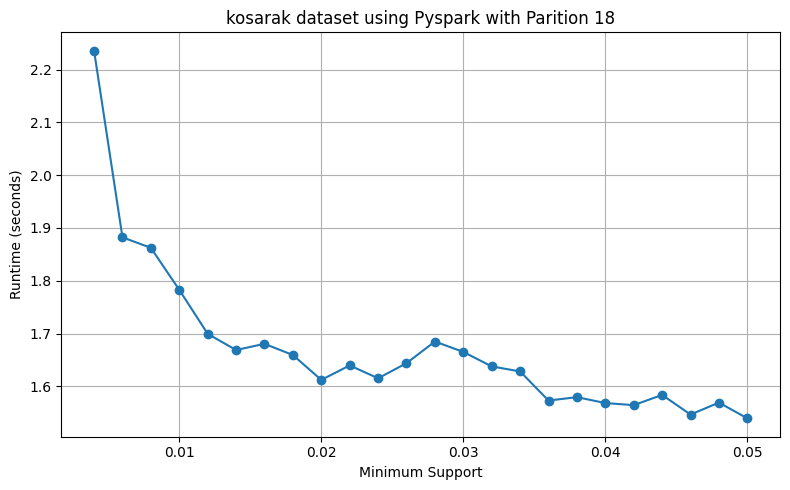

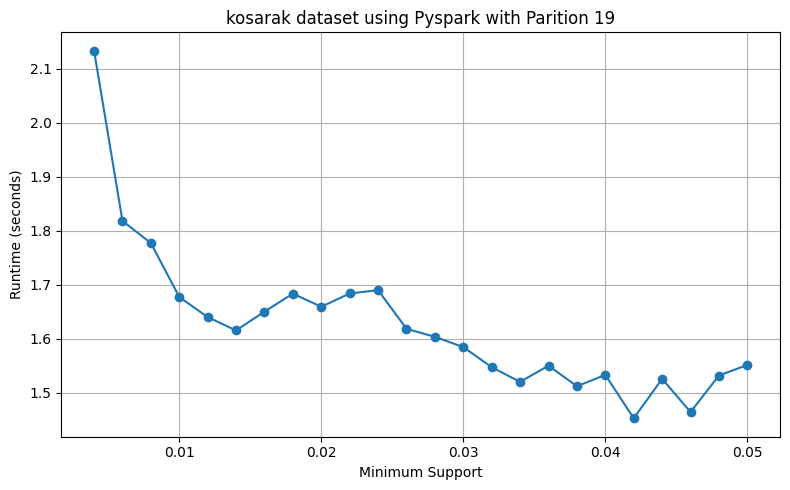

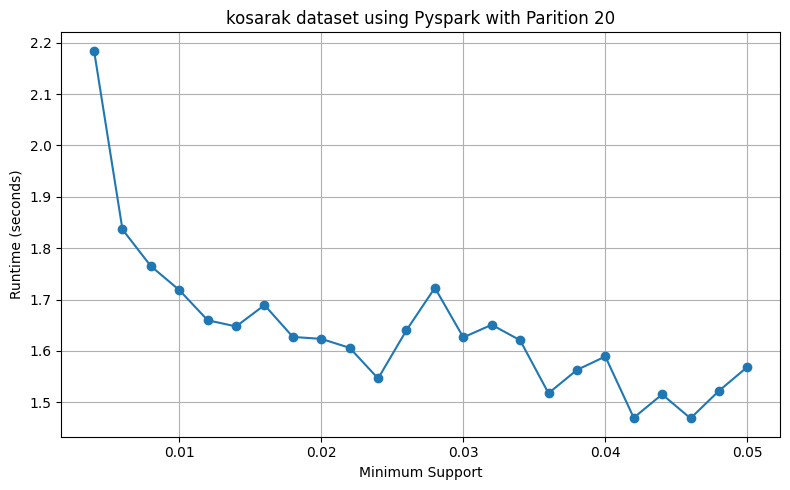

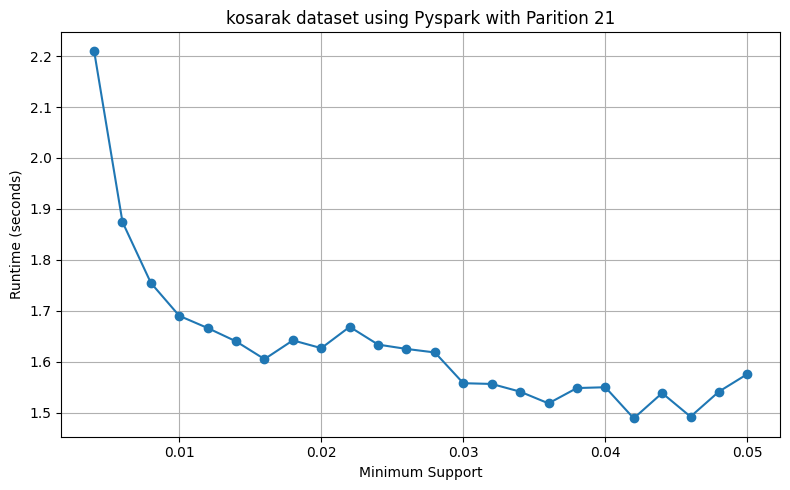

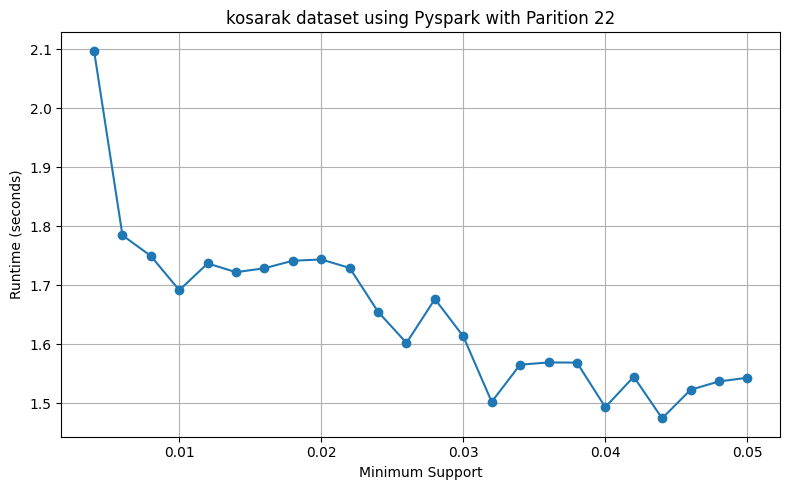

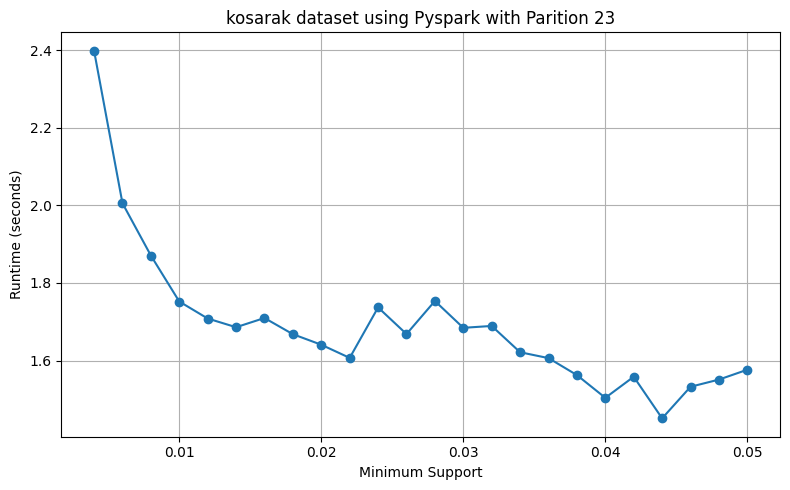

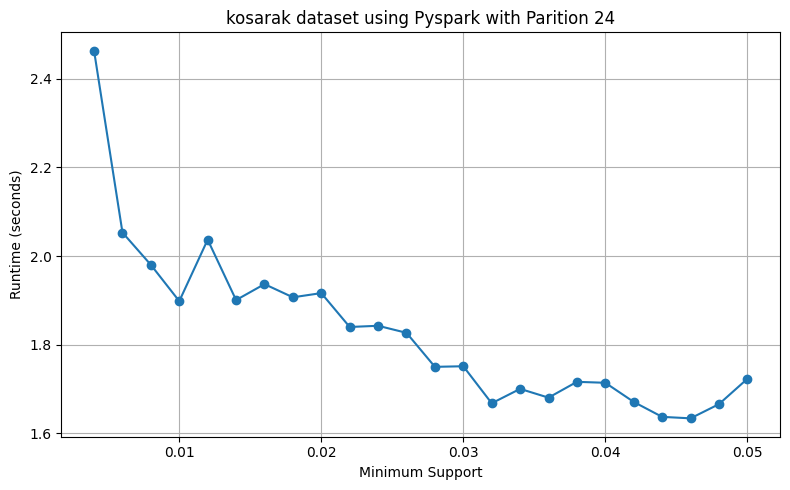

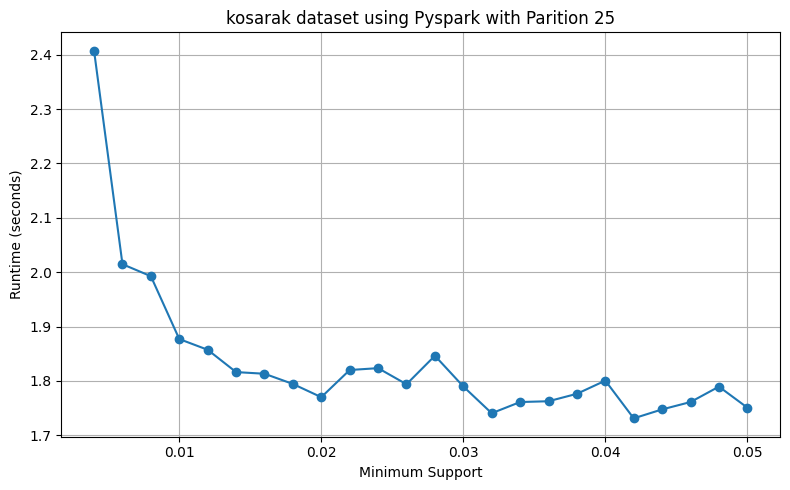

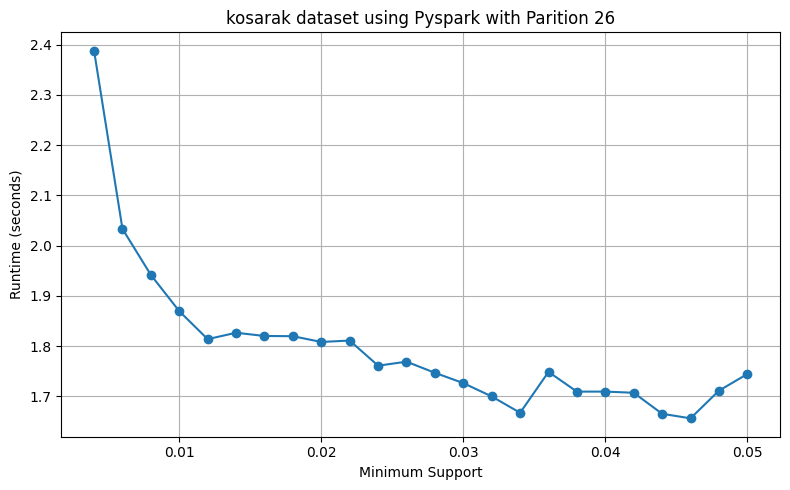

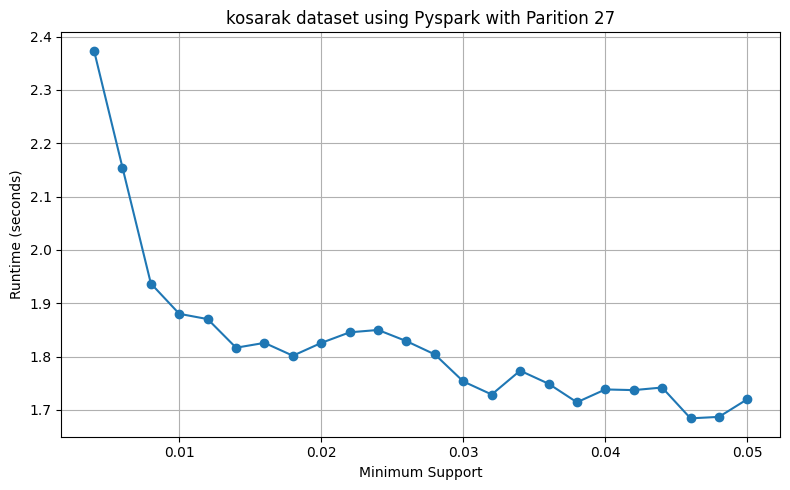

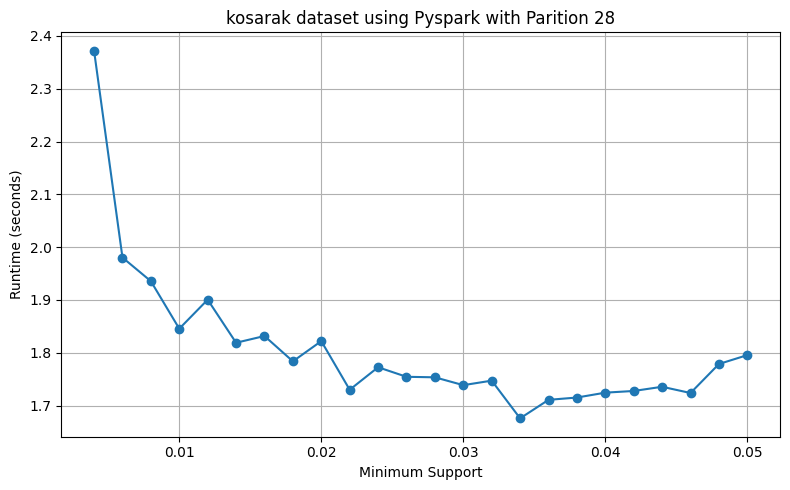

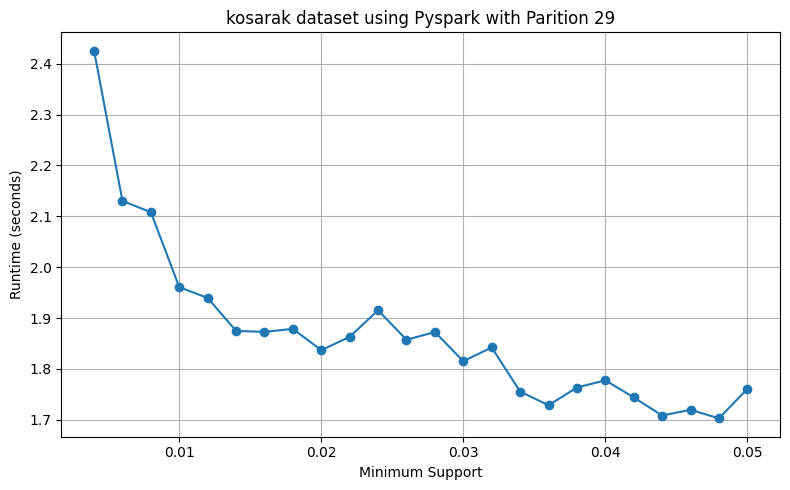

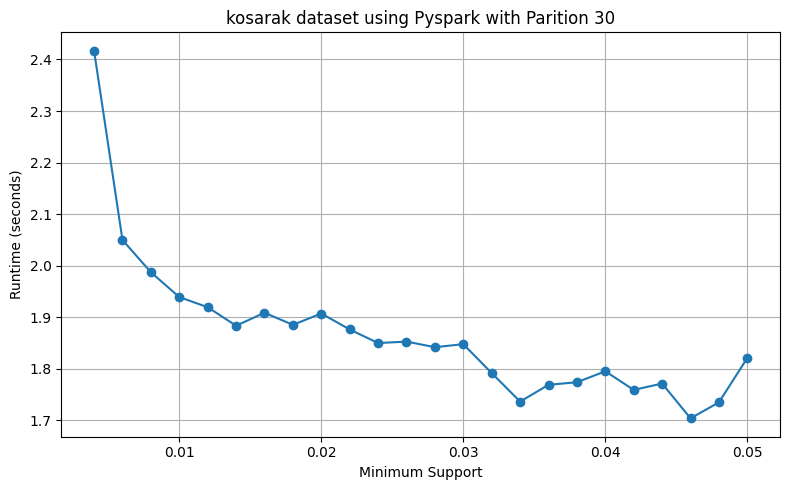

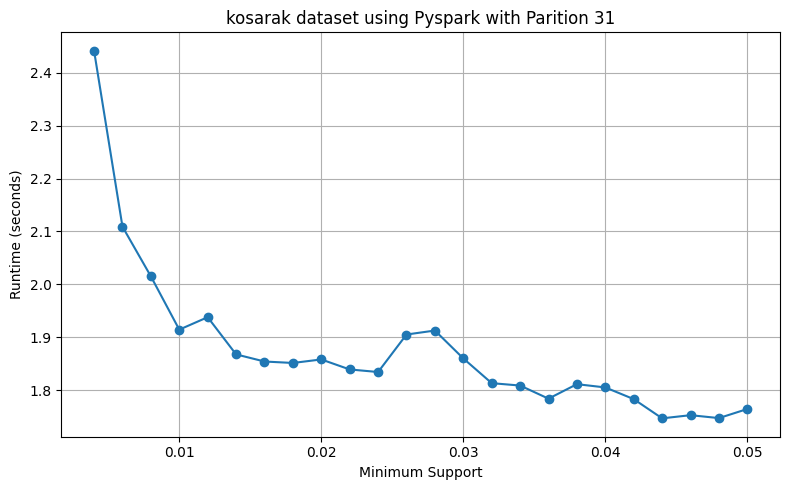

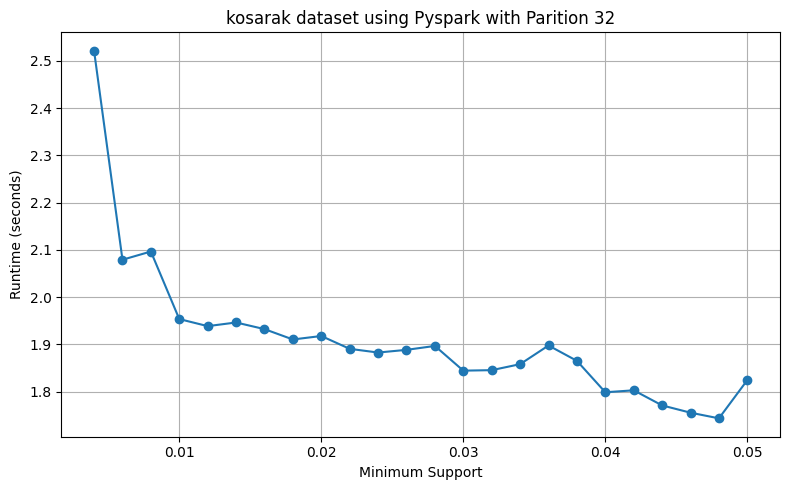

In [24]:
for dataset_name in ['T10I4D100K','kosarak']:
        for partition in range(2,33):
                csv_file_path= f"results/son/partition_{partition}/{dataset_name}.csv" 
                os.makedirs(os.path.dirname(csv_file_path), exist_ok=True)
                with open(csv_file_path, 'w', newline='') as csv_file:
                        csv_writer = csv.writer(csv_file)
                        csv_writer.writerow(['min_support', 'partition', 'elapsed'])
                        for min_support in range(5000,200,-200):
                                min_support/=100000
                                # print(f'\nStarting with {dataset_name} and min_suppot {min_support}')
                                start_time = time.time()
                                all_frequent_itemsets=main_loop(f'{dataset_name}.dat',partition, min_support, spark)
                                end_time = time.time()  
                                elapsed = end_time - start_time
                                csv_writer.writerow([min_support,partition, elapsed])
                                csv_file.flush()
                                # print(f'Ending with {dataset_name} and min_suppot {min_support} in {elapsed} secs')
                plot_graph(csv_file_path,dataset_name, partition)

In [ ]:
def convert_efficient_apriori_output(apriori_itemsets_dict):
    converted_results = []
    for length, itemsets_of_length in apriori_itemsets_dict.items():
        for itemset_tuple, count in itemsets_of_length.items():
            converted_results.append((frozenset(itemset_tuple), count))
    converted_results.sort(key=lambda x: (str(sorted(list(x[0]))), x[1]))
    return converted_results


In [ ]:
def reliably_compare_frequent_itemsets(apriori_results,son_results):
    comparison_report = {
        "status": "Identical",
        "mismatches": [],
        "apriori_count": len(apriori_results),
        "son_count": len(son_results)
    }

    if len(apriori_results) != len(son_results):
        comparison_report["status"] = "Mismatched Counts"
        comparison_report["mismatches"].append(
            f"Different number of frequent itemsets: "
            f"Apriori has {len(apriori_results)}, SON has {len(son_results)}."
        )

    apriori_map = {itemset: count for itemset, count in apriori_results}
    son_map = {itemset: count for itemset, count in son_results}

    apriori_itemsets_only = set(apriori_map.keys()) - set(son_map.keys())
    son_itemsets_only = set(son_map.keys()) - set(apriori_map.keys())

    if apriori_itemsets_only:
        comparison_report["status"] = "Mismatched Itemsets"
        comparison_report["mismatches"].append(
            f"Itemsets found ONLY in efficient_apriori: {apriori_itemsets_only}"
        )
    if son_itemsets_only:
        comparison_report["status"] = "Mismatched Itemsets"
        comparison_report["mismatches"].append(
            f"Itemsets found ONLY in PySpark SON: {son_itemsets_only}"
        )

    if comparison_report["status"] != "Identical":
        return comparison_report

    for itemset, apriori_count in apriori_map.items():
        son_count = son_map.get(itemset)
        if son_count is None:
            comparison_report["status"] = "Mismatched Itemsets (missing in SON)"
            comparison_report["mismatches"].append(f"Itemset {itemset} from Apriori not found in SON (despite set check).")
            continue

        if apriori_count != son_count:
            comparison_report["status"] = "Mismatched Counts"
            comparison_report["mismatches"].append(
                f"Count mismatch for itemset {itemset}: "
                f"Apriori={apriori_count}, SON={son_count}"
            )
            
    if not comparison_report["mismatches"]:
        comparison_report["status"] = "Identical"
    else:
        if comparison_report["status"] == "Identical":
             comparison_report["status"] = "Mismatches Found"

    return comparison_report

In [ ]:
from efficient_apriori import apriori
from util import load_file


def validate_result():
    test_min_support= 50/10000
    test_transactions_list = load_file('T10I4D100K',50000)
    print(len(test_transactions_list), "test_transactions_list")
    frequent_item_sets, rules = apriori(test_transactions_list, min_support=test_min_support)
    pyspark_test_transactions_rdd= spark.sparkContext.parallelize(test_transactions_list)# load_transactions('T10I4D100K.dat',2,spark,5000)
    partitioned_rdd = pyspark_test_transactions_rdd.repartition(2)
    test_candidates_rdd = son_phase1(partitioned_rdd, test_min_support)
    frequent_itemsets_rdd = son_phase2(partitioned_rdd, test_candidates_rdd, test_min_support)
    # print(frequent_itemsets_rdd.collect())
    # print(frequent_item_sets, "frequent_item_sets")
    apriori_final_results = convert_efficient_apriori_output(frequent_item_sets)
    comparison_report_t10k = reliably_compare_frequent_itemsets(apriori_final_results, frequent_itemsets_rdd.collect())
    print(comparison_report_t10k)
    if comparison_report_t10k["mismatches"]:
        for mismatch in comparison_report_t10k["mismatches"]:
            print(f"  - {mismatch}")


   
#     pass

In [ ]:
validate_result()